In [2]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt

Potrzebuję metodę bisekcji:
Dane wejściowe: funkcja, argument1, argument2, błąd docelowy
Dane wyjściowe: pierwiastek

In [90]:
λ = -(1/10) + 1j # stała λ

# funkcja metody bisekcji
def bisect(f, arg1, arg2, e):
    while np.abs(arg1 - arg2) > e:
        if f(arg1) * f((arg1 + arg2)/2) < 0:
            arg2 = (arg1 + arg2)/2
        else:
            arg1 = (arg1 + arg2)/2
    return (arg1 + arg2)/2

R = lambda h: np.abs(1 + (λ * h) + ((λ * h)**2)/2) - 1

h_gran = bisect(R, 1/2, 2, 10**(-12))
print(h_gran)

1.0424613808173717


Warto mieć w pamięci wzory definiujące metody Rungego-Kutny:
$$
x_{k+1} = x_k + h\sum_{i=1}^{s}{b_i K_i},\quad K_i = f\bigg( t_k + c_i h,\space x_k + h\sum_{j=1}^{s}{a_{ij} K_j}\bigg),\quad i = 1, 2,\dots , s.
$$

Schemat Heunego, użyty w tym zadaniu, ma postać:
$$
A' = \begin{bmatrix}
0 & 0 \\
1/2 & 0
\end{bmatrix},\space
b^T = \begin{bmatrix}
\frac{1}{2} & \frac{1}{2}
\end{bmatrix},\space
c = \begin{bmatrix}
0 \\
\frac{1}{2}
\end{bmatrix}.
$$

Schemat ten pociąga wzór:
$$ x_{k+1} = x_k + \frac{h}{2} f(t_k ,\space x_k) + \frac{h}{2} f\Big( t_k + \frac{h}{2},\space x_k + \frac{h}{2}f(t_k ,x_k )\Big) $$

W naszym przypadku funkcja f to macierz 
$$
A = \begin{bmatrix}
-\frac{1}{10} & 1 \\
-1 & -\frac{1}{10}
\end{bmatrix},
$$
natomiast wartość początkowa to
$$
x(0)=\begin{bmatrix}
\frac{1}{2} \\
-\frac{1}{3}
\end{bmatrix}
$$

In [102]:
Ap = sp.Matrix([[0, 0], # macierz A metody rungego kutny
               [0.5, 0]])
x0 = sp.Matrix([1/2, -1/3]) # macierz warunków początkowych
b = sp.Matrix([1/2, 1/2]) # macierz b metody rungego kutny
c = sp.Matrix([0, 1/2]) # macierz c metody rungego kutny

A = sp.Matrix([[-1/10, 1], [-1, -1/10]]) # macierz prawej strony równania różniczkowego

f = lambda x: A*x # funkcja prawej strony równania różniczkowego

# f(x0)
K1 = lambda x: f(x) # wektor K1 metody RK

K2 = lambda x, h: f(x + (h/2)*K1(x)) # wektor K2 metody RK

nast = lambda xk, h: xk + h*(b[0]*K1(xk) + b[1]*K2(xk, h)) # funkcja zwracająca x_{k+1}
# nast = lambda xk, h: xk + (h/2)*f(xk) + (h/2)*f(xk + (h/2)*f(xk))

def rozwiazanie(a, i): # funkcja zwracająca listę wektorów przybliżeń
    xk = x0
    rozw1 = [x0[0]]
    rozw2 = [x0[1]]
    for k in range(i-1):
        xk1 = nast(xk, a)
        rozw1.append(xk1[0])
        rozw2.append(xk1[1])
        xk = xk1
    return rozw1, rozw2


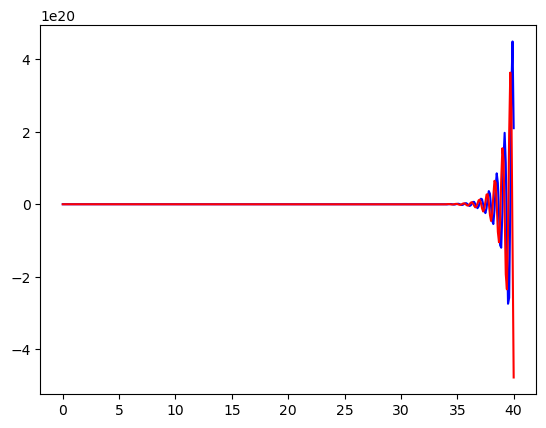

In [103]:
fig, ax = plt.subplots()
ax.plot(np.linspace(0, 40, 400), rozwiazanie(0.9*h_gran, 400)[0], color = 'b')
ax.plot(np.linspace(0, 40, 400), rozwiazanie(0.9*h_gran, 400)[1], color = 'r')
plt.show()

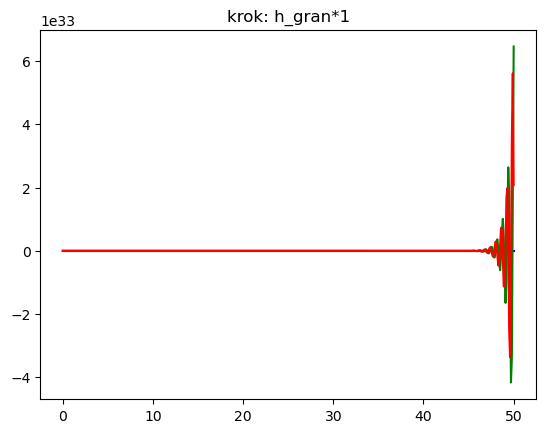

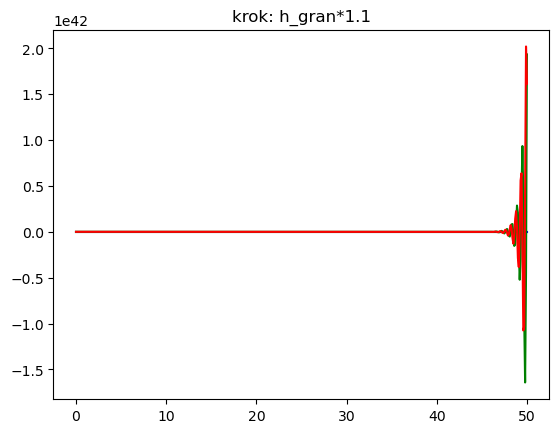

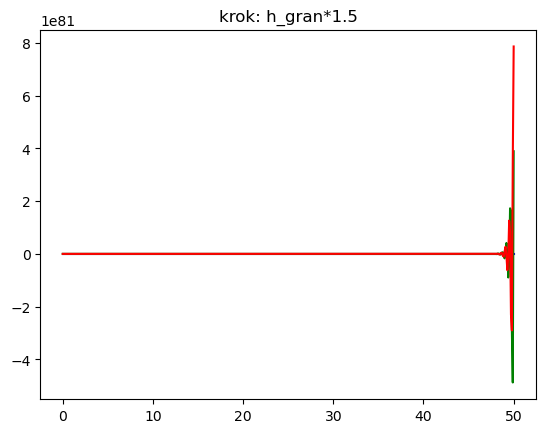

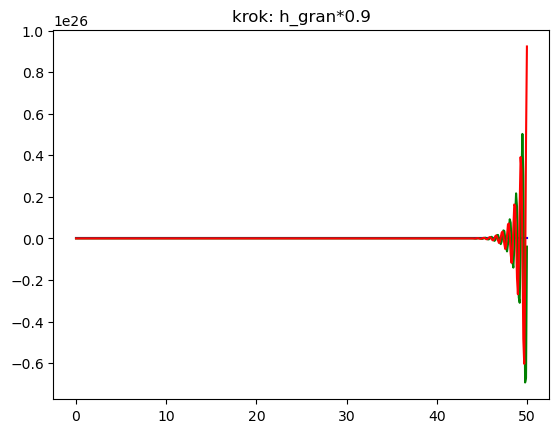

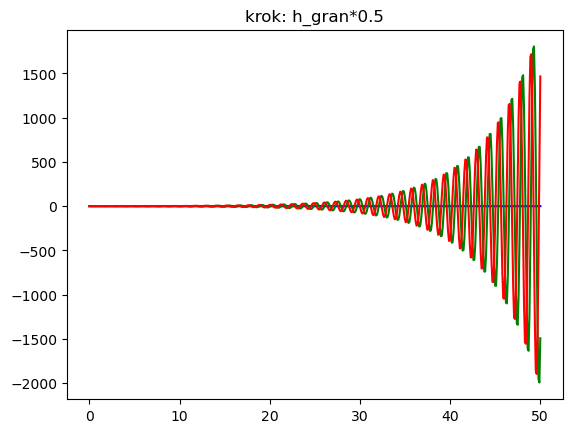

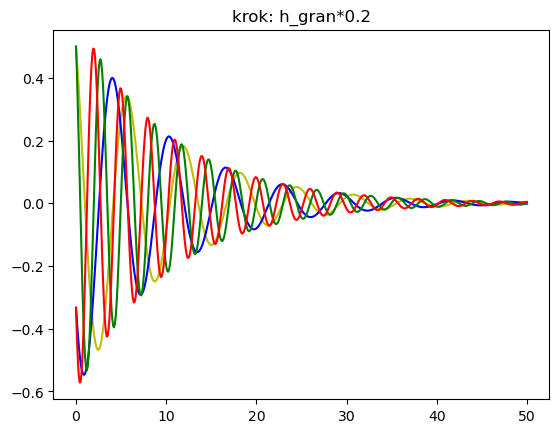

In [104]:
sol1 = lambda t: (1/6)*np.exp(-t/10)*(3*np.cos(t) - 2*np.sin(t))
sol1 = np.vectorize(sol1)
sol2 = lambda t: -(1/6)*np.exp(-t/10)*(3*np.sin(t) + 2*np.cos(t))
sol2 = np.vectorize(sol2)
hs = [1, 1.1, 1.5, 0.9, 0.5, 0.2]
time = np.linspace(0, 50, 500)
for a in hs:
    plt.plot(time, sol1(time), color = 'y')
    plt.plot(time, sol2(time), color = 'b')
    plt.plot(time, rozwiazanie(a*h_gran, 500)[0], color = 'g')
    plt.plot(time, rozwiazanie(a*h_gran, 500)[1], color = 'r')
    plt.title(f'krok: h_gran*{a}')
    plt.show()